**Industry Level Machine Learning Project**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#STEP 1 — IMPORT LIBRARIES

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')




## STEP 2 — LOAD DATASET

In [6]:
df=pd.read_csv("/content/drive/MyDrive/Module2_by Abishek/COVID_Vaccine_Prediction_Dataset_100000.csv")
df

,Person_ID,Age,Gender,State,Chronic_Disease,Previous_COVID,Doctor_Recommendation,Trust_in_Vaccine,Fear_of_Side_Effects,Vaccine_Type_Preference,Will_Take_Vaccine
0,1,32,Male,UP,Yes,Yes,Yes,1,5,Sputnik,Yes
1,2,72,Male,Karnataka,Yes,Yes,Yes,1,1,Sputnik,Yes
2,3,43,Female,UP,Yes,No,Yes,9,7,Moderna,Yes
3,4,61,Male,UP,No,No,Yes,5,3,Covaxin,Yes
4,5,63,Female,Karnataka,Yes,Yes,No,6,10,Moderna,Yes
...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,38,Female,Bihar,No,No,Yes,9,2,Sputnik,Yes
99996,99997,47,Female,Maharashtra,No,Yes,Yes,7,1,Sputnik,Yes
99997,99998,51,Male,Maharashtra,Yes,No,No,6,1,Sputnik,Yes
99998,99999,46,Male,Bihar,Yes,Yes,No,5,8,Moderna,Yes


STEP 3 — UNDERSTAND DATASET


In [7]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.columns)

(100000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Person_ID                100000 non-null  int64 
 1   Age                      100000 non-null  int64 
 2   Gender                   100000 non-null  object
 3   State                    100000 non-null  object
 4   Chronic_Disease          100000 non-null  object
 5   Previous_COVID           100000 non-null  object
 6   Doctor_Recommendation    100000 non-null  object
 7   Trust_in_Vaccine         100000 non-null  int64 
 8   Fear_of_Side_Effects     100000 non-null  int64 
 9   Vaccine_Type_Preference  100000 non-null  object
 10  Will_Take_Vaccine        100000 non-null  object
dtypes: int64(4), object(7)
memory usage: 8.4+ MB
None
           Person_ID            Age  Trust_in_Vaccine  Fear_of_Side_Effects
count  100000.000000  100000.000000     1000

# STEP 4 — CHECK MISSING VALUES

In [8]:
print(df.isnull().sum())

Person_ID                  0
Age                        0
Gender                     0
State                      0
Chronic_Disease            0
Previous_COVID             0
Doctor_Recommendation      0
Trust_in_Vaccine           0
Fear_of_Side_Effects       0
Vaccine_Type_Preference    0
Will_Take_Vaccine          0
dtype: int64


In [9]:
print(df.isnull().sum().sum())
df.shape

0


(100000, 11)

STEP 5 — HANDLE MISSING VALUES

In [10]:
# if Missing Value is present then use this Step Otherwise skip the step

categorical_cols=df.select_dtypes(include=['object']).columns
numerical_cols=df.select_dtypes(include=['int64','float64']).columns
print(categorical_cols)
print(numerical_cols)

for col in categorical_cols:
  df[col].fillna(df[col].mode()[0],inplace=True)

for col in numerical_cols:
  df[col].fillna(df[col].mean(),inplace=True)



Index(['Gender', 'State', 'Chronic_Disease', 'Previous_COVID',
       'Doctor_Recommendation', 'Vaccine_Type_Preference',
       'Will_Take_Vaccine'],
      dtype='object')
Index(['Person_ID', 'Age', 'Trust_in_Vaccine', 'Fear_of_Side_Effects'], dtype='object')


In [11]:
print(df.isnull().sum().sum())
print(df.isnull().sum())
df.head()


0
Person_ID                  0
Age                        0
Gender                     0
State                      0
Chronic_Disease            0
Previous_COVID             0
Doctor_Recommendation      0
Trust_in_Vaccine           0
Fear_of_Side_Effects       0
Vaccine_Type_Preference    0
Will_Take_Vaccine          0
dtype: int64


,Person_ID,Age,Gender,State,Chronic_Disease,Previous_COVID,Doctor_Recommendation,Trust_in_Vaccine,Fear_of_Side_Effects,Vaccine_Type_Preference,Will_Take_Vaccine
0,1,32,Male,UP,Yes,Yes,Yes,1,5,Sputnik,Yes
1,2,72,Male,Karnataka,Yes,Yes,Yes,1,1,Sputnik,Yes
2,3,43,Female,UP,Yes,No,Yes,9,7,Moderna,Yes
3,4,61,Male,UP,No,No,Yes,5,3,Covaxin,Yes
4,5,63,Female,Karnataka,Yes,Yes,No,6,10,Moderna,Yes


## STEP 6 — CHECK DUPLICATE RECORDS

In [12]:
print(df.duplicated().sum())

0


## STEP 7 — REMOVE DUPLICATES

In [13]:
df.drop_duplicates(inplace=True)

## STEP 8 — EXPLORATORY DATA ANALYSIS (EDA)

# WHAT IS EDA?

EDA = Exploratory Data Analysis

**Purpose:**

* Understand data

* Find patterns

* Detect outliers

* Detect relationships

* Generate business insights


# STEP 9 — TARGET VARIABLE ANALYSIS

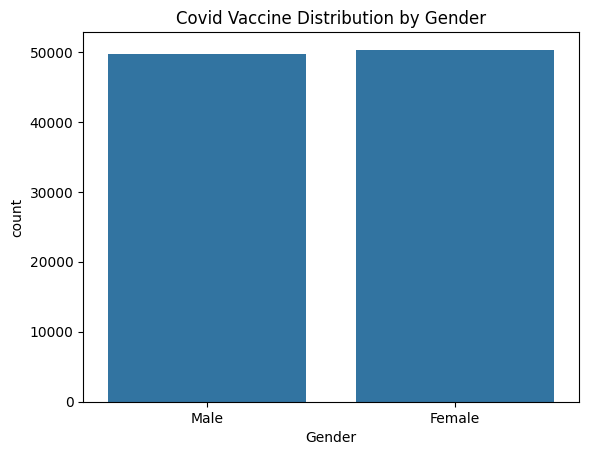

In [14]:
# =====================================================
# TARGET VARIABLE VISUALIZATION
# =====================================================

# countplot() creates frequency graph
# x parameter defines target column

sns.countplot(x='Gender', data=df)

# title() adds graph title
plt.title('Covid Vaccine Distribution by Gender')

# show() displays graph
plt.show()

## STEP 10 — CORRELATION HEATMAP

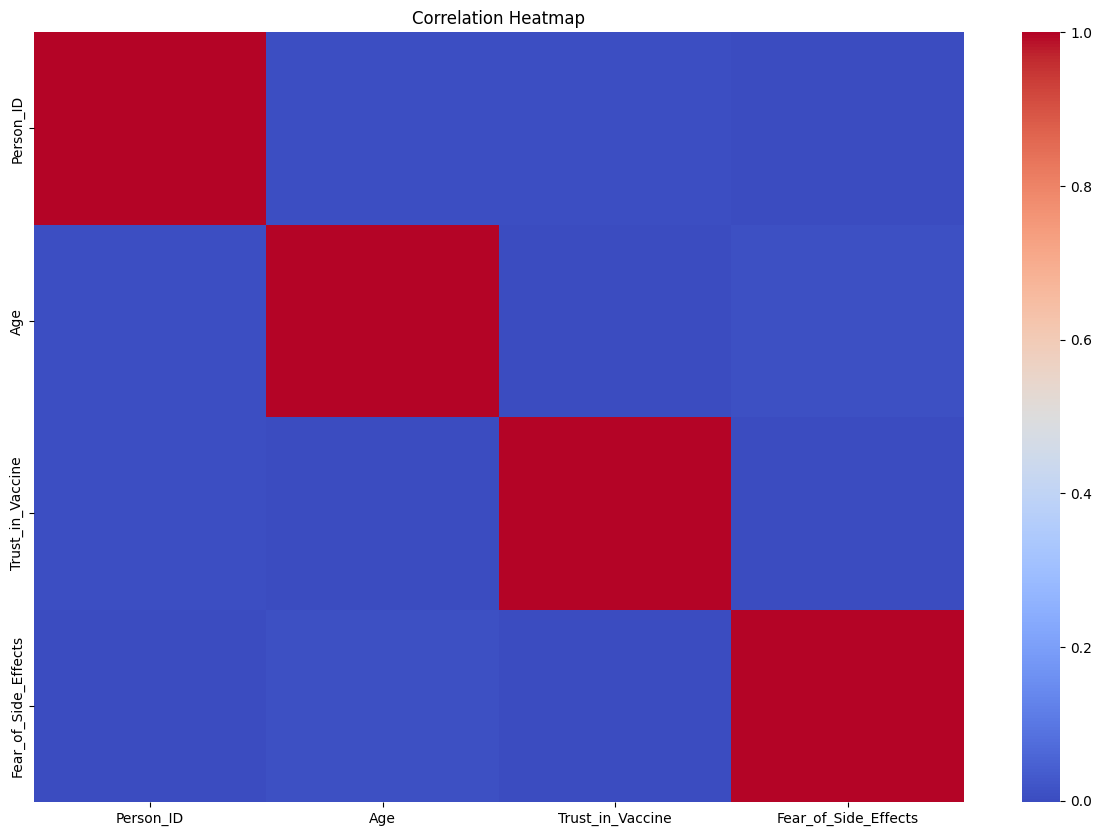

In [15]:
# =====================================================
# CORRELATION ANALYSIS
# =====================================================

# corr() calculates relationship between columns
correlation = df.corr(numeric_only=True)

# figure() sets graph size
plt.figure(figsize=(15,10))

# heatmap() creates correlation matrix
sns.heatmap(correlation, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [16]:
df

,Person_ID,Age,Gender,State,Chronic_Disease,Previous_COVID,Doctor_Recommendation,Trust_in_Vaccine,Fear_of_Side_Effects,Vaccine_Type_Preference,Will_Take_Vaccine
0,1,32,Male,UP,Yes,Yes,Yes,1,5,Sputnik,Yes
1,2,72,Male,Karnataka,Yes,Yes,Yes,1,1,Sputnik,Yes
2,3,43,Female,UP,Yes,No,Yes,9,7,Moderna,Yes
3,4,61,Male,UP,No,No,Yes,5,3,Covaxin,Yes
4,5,63,Female,Karnataka,Yes,Yes,No,6,10,Moderna,Yes
...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,38,Female,Bihar,No,No,Yes,9,2,Sputnik,Yes
99996,99997,47,Female,Maharashtra,No,Yes,Yes,7,1,Sputnik,Yes
99997,99998,51,Male,Maharashtra,Yes,No,No,6,1,Sputnik,Yes
99998,99999,46,Male,Bihar,Yes,Yes,No,5,8,Moderna,Yes


## IMPORTANT TERMS

| Term                 | Meaning                             |
| -------------------- | ----------------------------------- |
| Correlation          | Relationship between variables      |
| Positive Correlation | Variables increase together         |
| Negative Correlation | One increases while other decreases |
| Heatmap              | Color-based data visualization      |

## STEP 11 — ENCODING CATEGORICAL DATA

# WHY ENCODING IS NEEDED?

Machine Learning models understand only numbers.

Example:

* Male → 0
* Female → 1

In [17]:
#=============================================
# Label Encoding
#=============================================

from sklearn.preprocessing import LabelEncoder

#CREATING Encoder object
le=LabelEncoder()

for col in categorical_cols:
  df[col]=le.fit_transform(df[col])
  print(col)




Gender
State
Chronic_Disease
Previous_COVID
Doctor_Recommendation
Vaccine_Type_Preference
Will_Take_Vaccine


In [18]:
df


,Person_ID,Age,Gender,State,Chronic_Disease,Previous_COVID,Doctor_Recommendation,Trust_in_Vaccine,Fear_of_Side_Effects,Vaccine_Type_Preference,Will_Take_Vaccine
0,1,32,1,4,1,1,1,1,5,4,1
1,2,72,1,2,1,1,1,1,1,4,1
2,3,43,0,4,1,0,1,9,7,2,1
3,4,61,1,4,0,0,1,5,3,0,1
4,5,63,0,2,1,1,0,6,10,2,1
...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,38,0,0,0,0,1,9,2,4,1
99996,99997,47,0,3,0,1,1,7,1,4,1
99997,99998,51,1,3,1,0,0,6,1,4,1
99998,99999,46,1,0,1,1,0,5,8,2,1


## IMPORTANT TERMS

| Term            | Meaning                      |
| --------------- | ---------------------------- |
| Encoding        | Converting text into numbers |
| Label Encoding  | Assigning numeric labels     |
| fit_transform() | Learn + convert data         |


# STEP 12 — DEFINE FEATURES AND TARGET

In [19]:
# =====================================================
# DEFINING INPUT AND OUTPUT VARIABLES
# =====================================================

# X contains independent variables
# Features used for prediction
x=df.drop(["Will_Take_Vaccine", "Person_ID", "Doctor_Recommendation"],axis=1)

# y contains target variable
# Output column
y=df['Will_Take_Vaccine']

## IMPORTANT TERMS

| Term                 | Meaning          |
| -------------------- | ---------------- |
| Independent Variable | Input features   |
| Dependent Variable   | Output feature   |
| axis=1               | Column operation |

## STEP 13 — TRAIN TEST SPLIT

In [20]:
# =====================================================
# SPLITTING DATA
# =====================================================

# train_test_split divides data into:
# - Training data
# - Testing data

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

print(X_train)
print(y_train)
print(X_test)
print(y_test)





(80000, 8)
(20000, 8)
(80000,)
(20000,)
       Age  Gender  State  Chronic_Disease  Previous_COVID  Trust_in_Vaccine  \
75220   59       0      0                0               0                 3   
48955   76       1      2                1               0                 1   
44966   68       1      3                0               1                 9   
13568   26       0      3                1               1                 3   
92727   43       1      1                1               0                 1   
...    ...     ...    ...              ...             ...               ...   
6265    50       0      3                0               0                 2   
54886   62       1      0                0               0                 1   
76820   41       1      1                1               1                 4   
860     65       1      3                0               1                 2   
15795   67       0      0                0               1                 8   


# WHY TRAIN TEST SPLIT?

## Training Data

Used to train model.

## Testing Data

Used to check model performance on unseen data.

# IMPORTANT TERMS

| Term           | Meaning                              |
| -------------- | ------------------------------------ |
| test_size=0.2  | 20% data for testing                 |
| random_state   | Ensures same random split every time |
| Model Training | Learning patterns from data          |

## STEP 14 — FEATURE SCALING

# WHY SCALING IS NEEDED?

Some ML algorithms work better when all features are on same scale.

In [21]:
# =====================================================
# FEATURE SCALING
# =====================================================

from sklearn.preprocessing import StandardScaler

# Creating scaler object
scaler = StandardScaler()

# fit_transform() learns scaling from training data
X_train_scaled = scaler.fit_transform(X_train)


# transform() applies same scaling to testing data
X_test_scaled = scaler.transform(X_test)
print(X_test_scaled)

[[-3.76492066e-01 -9.92354228e-01 -1.41060416e+00 ...  1.72838568e-01
  -5.23238571e-01  1.40779477e+00]
 [-1.29295080e+00 -9.92354228e-01 -7.05363786e-01 ... -8.71161540e-01
  -5.23238571e-01  1.40779477e+00]
 [ 4.38137917e-01 -9.92354228e-01 -1.41060416e+00 ...  8.68838640e-01
   1.21287494e+00  1.40779477e+00]
 ...
 [ 1.60916852e+00  1.00770468e+00 -1.23417065e-04 ... -1.56716161e+00
   8.65652240e-01 -1.41516977e+00]
 [-4.27406440e-01 -9.92354228e-01  7.05116952e-01 ...  1.21683868e+00
   5.18429537e-01  1.40779477e+00]
 [-1.64935141e+00  1.00770468e+00  1.41035732e+00 ...  1.56483871e+00
  -1.76015869e-01 -7.09428632e-01]]


# STEP 15 — MODEL BUILDING

# USING LOGISTIC REGRESSION

## WHY LOGISTIC REGRESSION?

Because:

* Best for classification problems
* Easy to interpret
* Industry standard baseline model


In [22]:
# =====================================================
# MODEL TRAINING
# =====================================================

# Importing Logistic Regression
from sklearn.linear_model import LogisticRegression

# Creating model object
model = LogisticRegression()

# fit() trains model using training data
model.fit(X_train_scaled, y_train)

LogisticRegression()

## IMPORTANT TERMS

| Term                | Meaning                         |
| ------------------- | ------------------------------- |
| Algorithm           | Mathematical learning method    |
| Model               | Trained machine learning system |
| fit()               | Training process                |
| Logistic Regression | Classification algorithm        |

## STEP 16 — MODEL PREDICTION

In [23]:
# =====================================================
# MAKING PREDICTIONS
# =====================================================

# predict() generates predictions
predictions = model.predict(X_test_scaled)

print(predictions)

[1 1 1 ... 1 1 1]


# IMPORTANT TERMS

| Term       | Meaning                         |
| ---------- | ------------------------------- |
| Prediction | Model output                    |
| Inference  | Using trained model on new data |

# STEP 17 — MODEL EVALUATION

In [24]:
# =====================================================
# MODEL PERFORMANCE CHECK
# =====================================================

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Accuracy calculation
accuracy = accuracy_score(y_test, predictions)

print('Accuracy:', accuracy)

# Confusion matrix
print(confusion_matrix(y_test, predictions))

# Classification report
print(classification_report(y_test, predictions))

Accuracy: 0.8652
[[  803  1878]
 [  818 16501]]
              precision    recall  f1-score   support

           0       0.50      0.30      0.37      2681
           1       0.90      0.95      0.92     17319

    accuracy                           0.87     20000
   macro avg       0.70      0.63      0.65     20000
weighted avg       0.84      0.87      0.85     20000



# IMPORTANT METRICS EXPLAINED

| Metric           | Meaning                              |
| ---------------- | ------------------------------------ |
| Accuracy         | Overall correct predictions          |
| Precision        | Correct positive predictions         |
| Recall           | Ability to detect positives          |
| F1 Score         | Balance between precision and recall |
| Confusion Matrix | Prediction comparison table          |

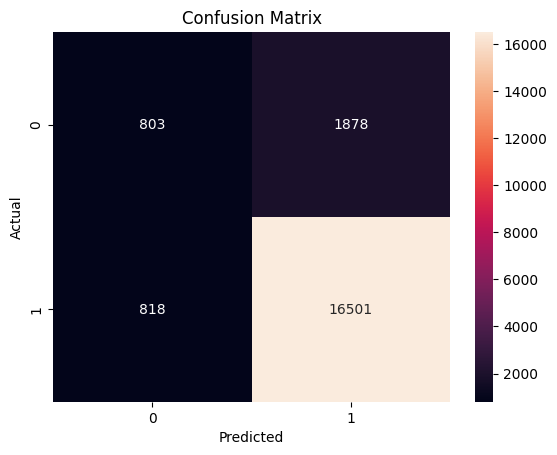

In [25]:
# STEP 18 — CONFUSION MATRIX VISUALIZATION
# =====================================================
# CONFUSION MATRIX HEATMAP
# =====================================================

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm,annot=True,fmt='d')# fmt means format,d means integer,f means float

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
# =========================================================
# Step 1 : Import Required Libraries
# =========================================================
# SMOTE = SYNTHETIC MINORITY OVER SAMPLING TECHNIQUE
from imblearn.over_sampling import SMOTE   # We  use  this for  data balancy
from collections import Counter            # It  check  class count

# =========================================================
# Step 2 : Check Original Data Distribution
# =========================================================

print("Original Dataset Shape:")
print(Counter(y))

# Example Output:
# {0: 3135, 1: 865}

# =========================================================
# Step 3 : Apply SMOTE
# =========================================================

# random_state = same result baar baar lane ke liye
smote = SMOTE(random_state=42)

# fit_resample() :
# X features aur y target ko balance karega
X_balanced, y_balanced = smote.fit_resample(x, y)

# =========================================================
# Step 4 : Check Balanced Data
# =========================================================

print("Balanced Dataset Shape:")
print(Counter(y_balanced))

# Example Output:
# {0: 3135, 1: 3135}

Original Dataset Shape:
Counter({1: 86214, 0: 13786})
Balanced Dataset Shape:
Counter({1: 86214, 0: 86214})


# Now again we train the data,test data and  apply model  and check  this.

In [27]:
# =========================================================
# STEP 1 : Train Test Split
# =========================================================

from sklearn.model_selection import train_test_split

# Balanced data ko split karna

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42
)

# =========================================================
# STEP 2 : Import Model
# =========================================================

from sklearn.ensemble import RandomForestClassifier

# =========================================================
# STEP 3 : Create Model
# =========================================================

model = RandomForestClassifier()

# =========================================================
# STEP 4 : Train Model
# =========================================================

# fit() model ko training deta hai

model.fit(X_train, y_train)

# =========================================================
# STEP 5 : Prediction
# =========================================================

y_pred = model.predict(X_test)

# =========================================================
# STEP 6 : Evaluation
# =========================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9241721278199849


## STEP 19 — FEATURE IMPORTANCE

In [28]:
importances = {
    'Feature': x.columns,
    'Importance': model.feature_importances_
}


#print(importances)

importances=pd.DataFrame(importances)

# Sorting important features
importances = importances.sort_values(by='Importance', ascending=False)

print(importances.head(10))

                   Feature  Importance
4           Previous_COVID    0.387173
5         Trust_in_Vaccine    0.190528
6     Fear_of_Side_Effects    0.181914
0                      Age    0.168832
2                    State    0.026527
7  Vaccine_Type_Preference    0.025878
3          Chronic_Disease    0.009975
1                   Gender    0.009173


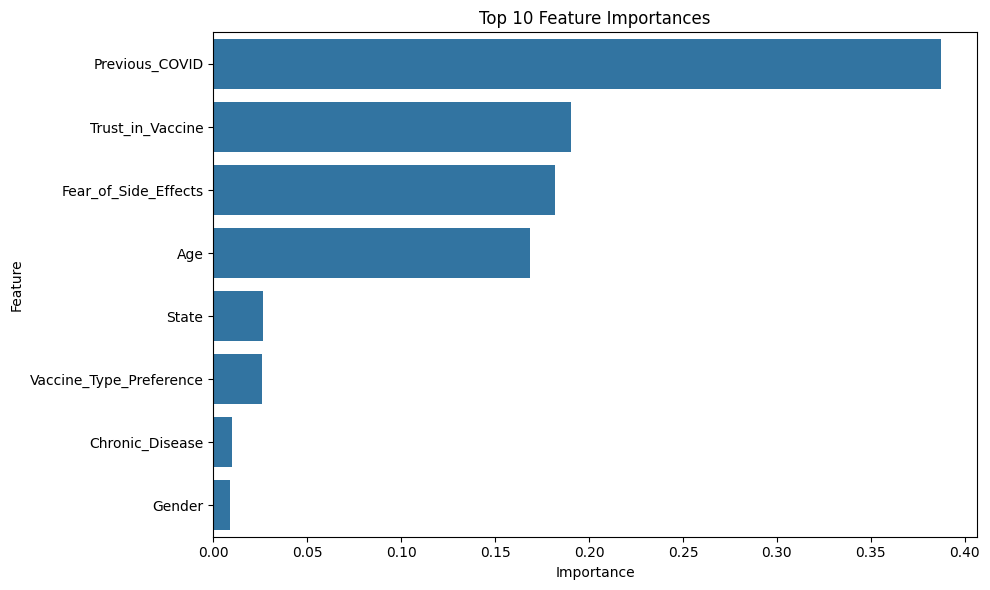

In [29]:
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances.head(20))
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [30]:
# STEP 20 — SAVE MODEL
# =====================================================
# SAVING TRAINED MODEL
# =====================================================

# joblib library saves ML models
import joblib

# dump() saves trained model file
joblib.dump(model, 'Covid_19_model.pkl')

print('Model Saved Successfully')

Model Saved Successfully
